## SAR Imagery Import

In [1]:
# import wandb
import torch
import pandas as pd
import numpy as np
import zipfile
import requests
from pathlib import Path

# ---------------------------------------------------------------------------
# Box download URLs — fill these in with your shared links
# Box direct download format: https://company.box.com/shared/static/<id>
# ---------------------------------------------------------------------------
BOX_URLS = {
    "os1": "https://virginia.box.com/shared/static/9tz0fm7kq6745qzgy22hia985uf6c3hz.zip",   # e.g. "https://company.box.com/shared/static/abc123"
    "os2": "https://virginia.box.com/shared/static/t5dt2l6dgc3oz8oeizj83e8938gx69yr.zip",
    "fs":  "https://virginia.box.com/shared/static/u1lmcljm3o75gseghv5acnd4417qrkn2.zip",
}

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
PROJECT_ROOT = Path("..").resolve()
DATA_DIR     = PROJECT_ROOT / "data" / "classification"
DATA_DIR.mkdir(parents=True, exist_ok=True)


def download_and_extract(key: str, out_dir: Path) -> None:
    """Download a zip from Box and extract it to out_dir."""
    url = BOX_URLS[key]
    if not url:
        print(f"[{key}] No URL provided, skipping.")
        return
    if out_dir.exists() and any(out_dir.iterdir()):
        print(f"[{key}] Already extracted, skipping.")
        return
    zip_path = DATA_DIR / f"{key}.zip"
    print(f"[{key}] Downloading...")
    dl_url = url + ("?dl=1" if "?" not in url else "&dl=1")
    with requests.get(dl_url, stream=True) as r:
        r.raise_for_status()
        with open(zip_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)
    print(f"[{key}] Extracting...")
    out_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(out_dir)
    zip_path.unlink()
    print(f"[{key}] Done -> {out_dir}")


# ---------------------------------------------------------------------------
# Download image folders
# ---------------------------------------------------------------------------
download_and_extract("os1", DATA_DIR / "os1")
download_and_extract("os2", DATA_DIR / "os2")
download_and_extract("fs",  DATA_DIR / "fs")

# ---------------------------------------------------------------------------
# Load CSVs (already in repo at data/classification/)
# ---------------------------------------------------------------------------
opensar1 = pd.read_csv(DATA_DIR / "opensar1_labels.csv")
opensar2 = pd.read_csv(DATA_DIR / "opensar2_labels.csv")
fusar    = pd.read_csv(DATA_DIR / "fusar_labels.csv")

# Resolve local image paths
opensar1["path"] = opensar1["path"].apply(lambda p: str(PROJECT_ROOT / p))
opensar2["path"] = opensar2["path"].apply(lambda p: str(PROJECT_ROOT / p))
fusar["path"]    = fusar["path"].apply(lambda p: str(PROJECT_ROOT / p))

print(f"OpenSARShip 1: {len(opensar1)} rows")
print(f"OpenSARShip 2: {len(opensar2)} rows")
print(f"FuSARShip:     {len(fusar)} rows")

fusar.head()

[os1] Already extracted, skipping.
[os2] Already extracted, skipping.
[fs] Already extracted, skipping.
OpenSARShip 1: 11346 rows
OpenSARShip 2: 18864 rows
FuSARShip:     5101 rows


,fs_id,path,class_label,ship_type,polarization,label,is_cargo,google_path
0,fs_0001,/sfs/gpfs/tardis/home/nbz3de/ds6050_final_proj...,Cargo/AggregatesCarrier,NaN,NaN,cargo,1,/content/drive/MyDrive/classification/fs/fs_00...
1,fs_0002,/sfs/gpfs/tardis/home/nbz3de/ds6050_final_proj...,Cargo/AggregatesCarrier,NaN,NaN,cargo,1,/content/drive/MyDrive/classification/fs/fs_00...
2,fs_0003,/sfs/gpfs/tardis/home/nbz3de/ds6050_final_proj...,Cargo/BulkCarrier,NaN,NaN,cargo,1,/content/drive/MyDrive/classification/fs/fs_00...
3,fs_0004,/sfs/gpfs/tardis/home/nbz3de/ds6050_final_proj...,Cargo/BulkCarrier,NaN,NaN,cargo,1,/content/drive/MyDrive/classification/fs/fs_00...
4,fs_0005,/sfs/gpfs/tardis/home/nbz3de/ds6050_final_proj...,Cargo/BulkCarrier,NaN,NaN,cargo,1,/content/drive/MyDrive/classification/fs/fs_00...


In [2]:
# import wandb
import torch
import pandas as pd
import numpy as np
from pathlib import Path
import gdown

DRIVE_FOLDER_URL = "https://drive.google.com/drive/folders/19jLMSzHChVLk-vVAg2muNN2OALzksWob"

# Local directory to download into — sits next to this notebook
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "classification"

# Download from Google Drive if CSVs are not already present
if not (DATA_DIR / "opensar1_labels.csv").exists():
    print("Downloading classification folder from Google Drive...")
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    gdown.download_folder(DRIVE_FOLDER_URL, output=str(DATA_DIR), quiet=False, use_cookies=False)
    print("Download complete.")
else:
    print(f"Data already present at {DATA_DIR}, skipping download.")

# Load all three label CSVs
opensar1 = pd.read_csv(DATA_DIR / "opensar1_labels.csv")
opensar2 = pd.read_csv(DATA_DIR / "opensar2_labels.csv")
fusar    = pd.read_csv(DATA_DIR / "fusar_labels.csv")

# Resolve image paths to absolute local paths
opensar1["path"] = opensar1["path"].apply(lambda p: str(PROJECT_ROOT / p))
opensar2["path"] = opensar2["path"].apply(lambda p: str(PROJECT_ROOT / p))
fusar["path"]    = fusar["path"].apply(lambda p: str(PROJECT_ROOT / p))

# print stats
print(f"OpenSARShip 1: {len(opensar1)} rows")
print(f"OpenSARShip 2: {len(opensar2)} rows")
print(f"FuSARShip:     {len(fusar)} rows")

fusar.head()

Data already present at /sfs/gpfs/tardis/home/nbz3de/ds6050_final_project/data/classification, skipping download.
OpenSARShip 1: 11346 rows
OpenSARShip 2: 18864 rows
FuSARShip:     5101 rows


,fs_id,path,class_label,ship_type,polarization,label,is_cargo,google_path
0,fs_0001,/sfs/gpfs/tardis/home/nbz3de/ds6050_final_proj...,Cargo/AggregatesCarrier,NaN,NaN,cargo,1,/content/drive/MyDrive/classification/fs/fs_00...
1,fs_0002,/sfs/gpfs/tardis/home/nbz3de/ds6050_final_proj...,Cargo/AggregatesCarrier,NaN,NaN,cargo,1,/content/drive/MyDrive/classification/fs/fs_00...
2,fs_0003,/sfs/gpfs/tardis/home/nbz3de/ds6050_final_proj...,Cargo/BulkCarrier,NaN,NaN,cargo,1,/content/drive/MyDrive/classification/fs/fs_00...
3,fs_0004,/sfs/gpfs/tardis/home/nbz3de/ds6050_final_proj...,Cargo/BulkCarrier,NaN,NaN,cargo,1,/content/drive/MyDrive/classification/fs/fs_00...
4,fs_0005,/sfs/gpfs/tardis/home/nbz3de/ds6050_final_proj...,Cargo/BulkCarrier,NaN,NaN,cargo,1,/content/drive/MyDrive/classification/fs/fs_00...


## Label Mapping and Filtering

In [3]:
# Build mapping from all unique labels across all three datasets
unique_labels = sorted(set(opensar1['label']).union(
                       set(opensar2['label'])).union(
                       set(fusar['label'])))

label_to_int = {label: i for i, label in enumerate(unique_labels)}

# Apply mapping independently
opensar1.loc[:, 'label_id'] = opensar1['label'].map(label_to_int)
opensar2.loc[:, 'label_id'] = opensar2['label'].map(label_to_int)
fusar.loc[:, 'label_id']    = fusar['label'].map(label_to_int)

print("Label mapping:", label_to_int)

# drop unknown values of the datasets
opensar1 = opensar1[opensar1['label'] != 'unknown']
opensar2 = opensar2[opensar2['label'] != 'unknown']
fusar    = fusar[fusar['label'] != 'unknown']

# length after creation
print(f"OpenSARShip 1: {len(opensar1)} rows")
print(f"OpenSARShip 2: {len(opensar2)} rows")
print(f"FuSARShip:     {len(fusar)} rows")

Label mapping: {'cargo': 0, 'engineering': 1, 'other': 2, 'passenger': 3, 'tanker': 4, 'unknown': 5}
OpenSARShip 1: 10602 rows
OpenSARShip 2: 16280 rows
FuSARShip:     5101 rows


## Dataset creation

In [4]:
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import ConcatDataset
from torchvision import transforms
from PIL import Image
import os

class create_dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        try:
            image = Image.open(row['path']).convert('L')  # load as grayscale
        except (FileNotFoundError, OSError) as e:
            raise RuntimeError(f"Error loading image at index {idx}: {row['path']}") from e

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(row['label_id'], dtype=torch.long)


# ImageNet normalization values expected by pretrained ResNet
RESNET_MEAN = [0.485, 0.456, 0.406]
RESNET_STD  = [0.229, 0.224, 0.225]

# Training transform — includes augmentation
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15, fill=0),
    transforms.ToTensor(),
    transforms.Normalize(mean=RESNET_MEAN, std=RESNET_STD)
])

# Validation/test transform — no augmentation
transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=RESNET_MEAN, std=RESNET_STD)
])

# Create two versions of each dataset: one for train, one for val/test
datasets_train = {
    'os1'  : create_dataset(opensar1, transform=transform_train),
    'os2'  : create_dataset(opensar2, transform=transform_train),
    'fusar': create_dataset(fusar,    transform=transform_train),
}
datasets_val = {
    'os1'  : create_dataset(opensar1, transform=transform_val),
    'os2'  : create_dataset(opensar2, transform=transform_val),
    'fusar': create_dataset(fusar,    transform=transform_val),
}

# Add combined entries
datasets_train['all'] = ConcatDataset(datasets_train.values())
datasets_val['all']   = ConcatDataset(datasets_val.values())

print(f"OpenSARShip 1: {len(datasets_train['os1'])} samples")
print(f"OpenSARShip 2: {len(datasets_train['os2'])} samples")
print(f"FuSARShip:     {len(datasets_train['fusar'])} samples")
print(f"Combined:      {len(datasets_train['all'])} samples")

OpenSARShip 1: 10602 samples
OpenSARShip 2: 16280 samples
FuSARShip:     5101 samples
Combined:      31983 samples


## Rebuild data loaders

In [9]:
import os
import torch
import pandas as pd
from torch.utils.data import ConcatDataset, Subset, DataLoader

# Add source column for 'all' stratification
opensar1['source'] = 'os1'
opensar2['source'] = 'os2'
fusar['source']    = 'fusar'

# Rebuild domains
domains = {
    'os1'  : {'df': opensar1},
    'os2'  : {'df': opensar2},
    'fusar': {'df': fusar},
    'all'  : {'df': pd.concat([opensar1, opensar2, fusar], ignore_index=True)},
}

# Load indices
loaded = np.load('split_indices.npz')

split_indices = {}
for key in loaded.files:
    domain, split = key.split('__', 1)
    split_indices.setdefault(domain, {})[split] = loaded[key].tolist()

# Rebuild datasets, dataloaders, and load best weights
for key in domains:
    idx       = split_indices[key]
    df        = domains[key]['df']
    labels    = df['label_id'].values
    train_idx = idx['train_idx']
    val_idx   = idx['val_idx']
    test_idx  = idx['test_idx']

    if key == 'all':
        full_train_ds = ConcatDataset(datasets_train.values())
        full_val_ds   = ConcatDataset(datasets_val.values())
        train_ds = Subset(full_train_ds, train_idx)
        val_ds   = Subset(full_val_ds,   val_idx)
        test_ds  = Subset(full_val_ds,   test_idx)
    else:
        train_ds = Subset(datasets_train[key], train_idx)
        val_ds   = Subset(datasets_val[key],   val_idx)
        test_ds  = Subset(datasets_val[key],   test_idx)

    domains[key]['train_loader'] = DataLoader(train_ds, batch_size=32, shuffle=True)
    domains[key]['val_loader']   = DataLoader(val_ds,   batch_size=32, shuffle=False)
    domains[key]['test_loader']  = DataLoader(test_ds,  batch_size=32, shuffle=False)

    print(f"Domain: {key}")
    print(f"  Train:      {len(train_idx)}")
    print(f"  Validation: {len(val_idx)}")
    print(f"  Test:       {len(test_idx)}")

    if key == 'all':
        for source in ['os1', 'os2', 'fusar']:
            source_mask = (df['source'] == source).values
            train_pct = source_mask[train_idx].sum() / len(train_idx) * 100
            val_pct   = source_mask[val_idx].sum()   / len(val_idx)   * 100
            test_pct  = source_mask[test_idx].sum()  / len(test_idx)  * 100
            print(f"  {source} breakdown -> train: {train_pct:.1f}%  val: {val_pct:.1f}%  test: {test_pct:.1f}%")

    # Class breakdown per split
    for split_name, split_idx in [('Train', train_idx), ('Val', val_idx), ('Test', test_idx)]:
        split_labels = labels[split_idx]
        unique, counts = np.unique(split_labels, return_counts=True)
        print(f"  {split_name} class breakdown:")
        for cls, cnt in zip(unique, counts):
            print(f"    class {cls}: {cnt:4d} ({cnt/len(split_idx)*100:.1f}%)")



Domain: os1
  Train:      7632
  Validation: 849
  Test:       2121
  Train class breakdown:
    class 0: 5932 (77.7%)
    class 1:  195 (2.6%)
    class 2:  276 (3.6%)
    class 3:   27 (0.4%)
    class 4: 1202 (15.7%)
  Val class breakdown:
    class 0:  660 (77.7%)
    class 1:   21 (2.5%)
    class 2:   31 (3.7%)
    class 3:    3 (0.4%)
    class 4:  134 (15.8%)
  Test class breakdown:
    class 0: 1648 (77.7%)
    class 1:   54 (2.5%)
    class 2:   77 (3.6%)
    class 3:    8 (0.4%)
    class 4:  334 (15.7%)
Domain: os2
  Train:      11721
  Validation: 1303
  Test:       3256
  Train class breakdown:
    class 0: 7842 (66.9%)
    class 1:  337 (2.9%)
    class 2:  631 (5.4%)
    class 3:  100 (0.9%)
    class 4: 2811 (24.0%)
  Val class breakdown:
    class 0:  872 (66.9%)
    class 1:   37 (2.8%)
    class 2:   70 (5.4%)
    class 3:   11 (0.8%)
    class 4:  313 (24.0%)
  Test class breakdown:
    class 0: 2179 (66.9%)
    class 1:   93 (2.9%)
    class 2:  175 (5.4%)
    cla

In [12]:
from torch.nn import Module, CrossEntropyLoss, Linear
from torchvision import models

class_names = [k for k, v in sorted(label_to_int.items(), key=lambda x: x[1]) if k != 'unknown']
print("class_names:", class_names)

class CNN_resnet_transfer(Module):
    def __init__(self):
        super().__init__()
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        num_features = self.resnet.fc.in_features
        self.resnet.fc = Linear(num_features, len(class_names))

        for param in self.resnet.parameters():
            param.requires_grad = False

        for name, param in self.resnet.named_parameters():
            if "layer3" in name or "layer4" in name or "fc" in name:
                param.requires_grad = True

    def forward(self, X):
        return self.resnet(X)

class_names: ['cargo', 'engineering', 'other', 'passenger', 'tanker']


## Load in best model weights

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for key in domains:
    model = CNN_resnet_transfer().to(device)

    weight_path = f"{key}_best.pth"
    if os.path.exists(weight_path):
        model.load_state_dict(torch.load(weight_path, map_location=device))
        print(f"Loaded weights: {weight_path}")
    else:
        print(f"WARNING: {weight_path} not found")

    domains[key]['trained_model'] = model

Loaded weights: os1_best.pth
Loaded weights: os2_best.pth
Loaded weights: fusar_best.pth


## Test/eval

In [ ]:
## Test Evaluation

def evaluate_test(model, model_name, test_loader, class_names):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    correct, total = 0, 0
    all_preds, all_labels = [], []

    # run predictions
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = 100. * correct / total
    print(f"[{model_name}] Test Accuracy: {acc:.2f}% ({correct}/{total})")

    # Per-class accuracy
    all_preds   = np.array(all_preds)
    all_labels  = np.array(all_labels)
    for i, name in enumerate(class_names):
        mask = all_labels == i
        if mask.sum() == 0:
            continue
        class_correct = (all_preds[mask] == i).sum()
        class_acc     = 100. * class_correct / mask.sum()
        print(f"  {name:15s}: {class_acc:.2f}% ({class_correct}/{mask.sum()} samples)")
    return acc, all_preds, all_labels


# Test each model against all test sets
results = {}  # results[model_key][test_key] = acc

for model_key in domains:
    print(f"\n{'='*40}")
    print(f"Model trained on: {model_key}")
    print(f"{'='*40}")
    results[model_key] = {}

    for test_key in domains:
        print(f"\n  -- Tested on: {test_key} --")
        acc, _, _ = evaluate_test(
            domains[model_key]['trained_model'],
            f"{model_key} -> {test_key}",
            domains[test_key]['test_loader'],
            class_names
        )
        results[model_key][test_key] = acc





Model trained on: os1

  -- Tested on: os1 --
[os1 -> os1] Test Accuracy: 79.63% (1689/2121)
  cargo          : 94.96% (1565/1648 samples)
  engineering    : 16.67% (9/54 samples)
  other          : 25.97% (20/77 samples)
  passenger      : 0.00% (0/8 samples)
  tanker         : 28.44% (95/334 samples)

  -- Tested on: os2 --


KeyboardInterrupt: 

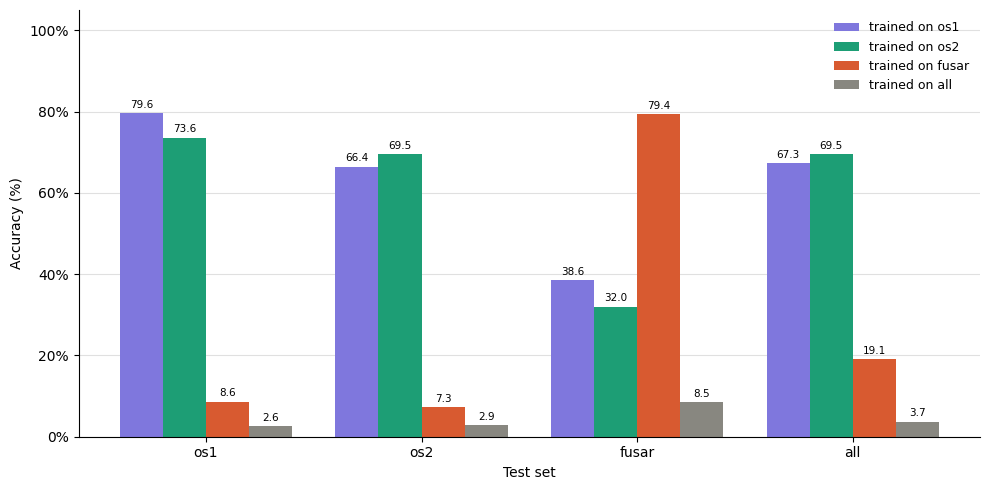

In [17]:
import matplotlib.pyplot as plt


# Plot grouped bar chart
domain_keys  = list(domains.keys())
model_colors = ['#7F77DD', '#1D9E75', '#D85A30', '#888780']

x     = np.arange(len(domain_keys))
n     = len(domain_keys)
width = 0.8 / n

fig, ax = plt.subplots(figsize=(10, 5))

for i, model_key in enumerate(domain_keys):
    accs    = [results[model_key][t] for t in domain_keys]
    offsets = x + i * width - (n - 1) * width / 2
    bars    = ax.bar(offsets, accs, width, label=f"trained on {model_key}", color=model_colors[i], linewidth=0)
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
                f"{acc:.1f}", ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(domain_keys)
ax.set_xlabel("Test set")
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', color='#e0e0e0', linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()